## Dataset Selection

Select a dataset identically to lab two (images). That is, the dataset must be image data. In terms of generalization performance, it is helpful to have a large dataset of identically sized images. It is fine to perform binary classification or multi-class classification. You are not allowed to use MNIST, Fashion, MNIST, or the sklearn digits dataset. 

## Preparation (3 points total)  
[1.5 points] Choose and explain what metric(s) you will use to evaluate your algorithm’s performance. You should give a detailed argument for why this (these) metric(s) are appropriate on your data. That is, why is the metric appropriate for the task (e.g., in terms of the business case for the task). Please note: rarely is accuracy the best evaluation metric to use. Think deeply about an appropriate measure of performance.
[1.5 points] Choose the method you will use for dividing your data into training and testing (i.e., are you using Stratified 10-fold cross validation? Shuffle splits? Why?). Explain why your chosen method is appropriate or use more than one method as appropriate. Convince me that your cross validation method is a realistic mirroring of how an algorithm would be used in practice. 

## Modeling (6 points total)
[1.5 points]  Setup the training to use data expansion in Keras (also called data augmentation). Explain why the chosen data expansion techniques are appropriate for your dataset. You should make use of Keras augmentation layers, like in the class examples.
[2 points] Create a convolutional neural network to use on your data using Keras. Investigate at least two different convolutional network architectures and investigate changing one or more parameters of each architecture such as the number of filters. This means, at a  minimum, you will train a total of four models (2 different architectures, with 2 parameters changed in each architecture). Use the method of train/test splitting and evaluation metric that you argued for at the beginning of the lab. Visualize the performance of the training and validation sets per iteration (use the "history" parameter of Keras). Be sure that models converge. 
[1.5 points] Visualize the final results of all the CNNs and interpret/compare the performances. Use proper statistics as appropriate, especially for comparing models. 
[1 points] Compare the performance of your convolutional network to a standard multi-layer perceptron (MLP) using the receiver operating characteristic and area under the curve. Use proper statistical comparison techniques.  

## Exceptional Work (1 points total)
You have free reign to provide additional analyses. 
One idea (required for 7000 level students): Use transfer learning with pre-trained weights for your initial layers of your CNN. Compare the performance when using transfer learning to your best model from above in terms of classification performance. 

In [1]:
#import libraries

import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape, Input
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D

keras.__version__

'3.13.2'

In [2]:
# retrieve the path to the csv file 
kaggle_path = kagglehub.dataset_download("mehrdadkianiosh/poker-cards-suits-and-numbers")
print(f"Path to dataset files: {kaggle_path}")

file_name = "PokerCards_dataset.csv"
file_path = os.path.join(kaggle_path, file_name)
print(f"Selected file: {file_path}")

Using Colab cache for faster access to the 'poker-cards-suits-and-numbers' dataset.
Path to dataset files: /kaggle/input/poker-cards-suits-and-numbers
Selected file: /kaggle/input/poker-cards-suits-and-numbers/PokerCards_dataset.csv


In [3]:
# Read the data and study the data types and missing values
df = pd.read_csv(file_path)

print(f'shape of raw dataset:', df.shape)

shape of raw dataset: (8851, 1121)


Below we will show all of the unique images in the dataset

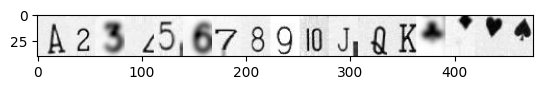

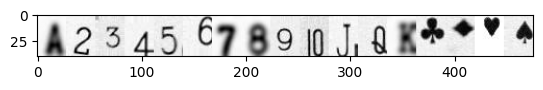

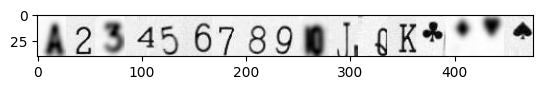

In [4]:
for i in range(3):
    image_list = [] # init the image list for visualization
    for label in df['label'].unique(): 
        row = df[df['label'] == label].iloc[i]

        image = row.drop('label').values.reshape(40, 28)
        image_list.append(image)

    image_stack = np.hstack(image_list)
    plt.imshow(image_stack, cmap = 'gray')
    plt.show()

For the train and test split, we will incorporate shuffle split with a stratify method. This shuffling will ensure that we are getting a well mixed result of training and testing data. At the same time, the stratify callout will ensure that we get a full distribution of labels across our data to test. In other words, we are preventing the random chance of getting only a subset of labels that the model actually has to predict. We choose to take this approach as opposed to a standard 80/20 test split because that would introduce risk of an "easy" draw or lack of even label distribution in the train/test data. 

In [5]:
def load_data(df, is_test = False):

    # divide the df into X and y then convert to numpy array
    y = df['label']
    y = y - 1 # change the 1-17 labels to 0-16 intead for the keras / TF process and to mitigate indexing errors
    X = df.drop(columns = 'label')

    y = y.to_numpy()
    X = X.to_numpy()

    labels = y.astype(np.uint8)
    images = X.astype(np.uint8)

    # Let's start by fixing the sizes, channels last and normalizing
    images = images/255.0
    images = np.expand_dims(images.reshape((-1,40,28)), axis=3)
    # the image data has been resized to (samples,image_rows,image_cols,image_channels)

    # and one hot encoding the output values
    global NUM_CLASSES
    NUM_CLASSES = len(np.unique(y))
    labels = keras.utils.to_categorical(labels, NUM_CLASSES)
    
    # create a dataset 
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    if not is_test:
        # only shuffle the training set
        dataset = dataset.shuffle(1024) # buffer size for shuffeling data
    dataset = dataset.batch(128)
    
    return dataset

In [6]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(file_path)

df_train, df_test = train_test_split(df, test_size = 0.2, random_state = 42, stratify = df['label'])

ds_train = load_data(df_train)
ds_test = load_data(df_test, is_test=True)

Here we establish the create_cnn_model function

In [7]:
%%time

def create_cnn_model(model_name, input_shape = [40,28,1], kernel_size= (3,3), pool_size=(2,2), 
                     filters_per_conv_layer = [32], # number of filters to use and how many convolutional layers to use 
                     dense_layer_sizes = [NUM_CLASSES], # number of neurons in each layer after flattening
                     use_dropout=False
                    ):
    
    cnn  = Sequential(name=model_name)
    cnn.add( Input(input_shape) )
    
    # convolutional layers
    for num_filters in filters_per_conv_layer:
        cnn.add( Conv2D(filters=num_filters, 
                        kernel_size=kernel_size, 
                        padding='same',
                        activation='relu',
                         ) )
        
        cnn.add( MaxPooling2D(pool_size=pool_size) )

    cnn.add( Flatten() )
    if len(dense_layer_sizes) > 1:
        # if layers preceding the final number of classes, make relu
        for num_hidden in dense_layer_sizes[:-2]:
            cnn.add( Dense(num_hidden, activation='relu') )
            # optionally use Dropout
            if use_dropout: cnn.add( Dropout(0.5) )
    # final layer for classes
    cnn.add( Dense(dense_layer_sizes[-1], activation='softmax') )

    return cnn


CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 10.5 µs


Here we establish the compare_models function

In [8]:
from sklearn import metrics as mt
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

def compare_models(models, ds_test, fig_size=(15,5), labels='auto'):
    ''' Plot confusion matrices for each model, with names
    '''
    plt.figure(figsize=fig_size)
    
    y_test = []
    for _, label_tensor in ds_test:
        # Convert the label tensor to a NumPy array and append it to the list
        y_test.append(label_tensor.numpy())
    y_test = np.argmax(np.vstack(y_test),axis=1) # stack into single array, get integer class

    # plot confusion matrices 
    num_plots = len(models)
    i = 1
    for model in models:
        yhat = np.argmax(model.predict(ds_test), axis=1)
        acc = mt.accuracy_score(y_test,yhat)

        cm = mt.confusion_matrix(y_test,yhat)
        cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
        
        plt.subplot(1,num_plots,i)
        
        sns.heatmap(cm, annot=True, fmt='.2f',xticklabels=labels, yticklabels=labels)
        plt.title(f'{model.name}: {acc:.4f}')
        i += 1
    

Here we will try models with the following architectures and parameters

Model 1 (CNN1)
Kernel size: 3x3
dense_layer_sizes: 50, NUM_CLASSES
Dropout?: False

Model 2 (CNN2)
Kernel size: 5x5
dense_layer_sizes: 50, NUM_CLASSES
Dropout?: False

Model 3 (CNN3)
Kernel size: 3x3
dense_layer_sizes: 256,50,NUM_CLASSES
Dropout?: True

Model 4 (CNN4)
Kernel size: 5x5
dense_layer_sizes: 256,50,NUM_CLASSES
Dropout?: True

The approach here is to separate the first two and last two models as separate architectures. The difference lies in the use_dropout being false for the first two and true for the 2nd two. Adding dropout usage makes the model stochastic since there is an element of randomness introduced. This is because the dropout will randomly turn off certain certain nodes in the network during training which will mitigate the risk of the model 'overfitting' the data. Additionally, it was decided to change the dense_layer_sizes from 50, 17 to 256, 50, 17. Increasing the dense_layer_sizes was done in order to expand the processing volume of the model to give it a larger "thinking" space. Note that NUM_CLASSES is equal to 17 since that is the number of labels. 

For our performance metrics, we will use a mix of accuracy and precision. We believe these are good metrics to use since they are simple to understand from a statiscal standpoint and both complement each other to provide a well rounded view of the model performance. Having both these is useful. For example, if we only used precision as the metric, we may be mislead by a high precision which in reality was only precision to a wrong prediction. Having accuracy and precision gives a broader picture of how well the model performs.

In [9]:
%%time

cnn1 = create_cnn_model(
    model_name  = 'PokerConvSmallSize_SmallKernel',
    input_shape = [40,28,1],
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,32], 
    dense_layer_sizes      = [50,NUM_CLASSES], 
    use_dropout = False
)

cnn2 = create_cnn_model(
    model_name  = 'PokerConvSmallSize_LargeKernel',
    input_shape = [40,28,1],
    kernel_size = (5,5), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,32], 
    dense_layer_sizes      = [50,NUM_CLASSES], 
    use_dropout = False
)

cnn3 = create_cnn_model(
    model_name  = 'PokerConvLargeSize_SmallKernel',
    input_shape = [40,28,1],
    kernel_size = (3,3), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,64], 
    dense_layer_sizes      = [256,50,NUM_CLASSES], 
    use_dropout = True
)

cnn4 = create_cnn_model(
    model_name  = 'PokerConvLargeSize_LargeKernel',
    input_shape = [40,28,1],
    kernel_size = (5,5), 
    pool_size   = (2,2), 
    filters_per_conv_layer = [32,64], 
    dense_layer_sizes      = [256,50,NUM_CLASSES],
    use_dropout = True 
)

histories = {} # init a dict to store performance results

for model in [cnn1, cnn2, cnn3, cnn4]:
    # Let's train the model 
    model.compile(loss='mean_squared_error',
                  optimizer='rmsprop',
                  metrics= ['accuracy', tf.keras.metrics.Precision(name = 'precision')])
    
    print(model.summary())
    
    # we need to exapnd the dimensions here to give the 
    #   "channels" dimension expected by Keras
    history = model.fit(ds_train, 
            batch_size=32, epochs=15, 
            shuffle=True, verbose=1,
            validation_data=ds_test)

    histories[model.name] = history.history


Model: "PokerConvSmallSize_SmallKernel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2240)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 17)             │        38,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,665 (186.19 KB)

 Trainable params: 47,665 (186.19 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 40, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 20, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4480)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,203,601 (4.59 MB)

 Trainable params: 1,203,601 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 28s 468ms/step - accuracy: 0.1256 - loss: 0.0546 - precision: 0.0000e+00 - val_accuracy: 0.2061 - val_loss: 0.0535 - val_precision: 0.0000e+00
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 465ms/step - accuracy: 0.3219 - loss: 0.0491 - precision: 0.8487 - val_accuracy: 0.5359 - val_loss: 0.0378 - val_precision: 0.8008
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 465ms/step - accuracy: 0.7493 - loss: 0.0221 - precision: 0.9235 - val_accuracy: 0.8656 - val_loss: 0.0115 - val_precision: 0.9425
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 462ms/step - accuracy: 0.8499 - loss: 0.0129 - precision: 0.9326 - val_accuracy: 0.8842 - val_loss: 0.0100 - val_precision: 0.9435
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 472ms/step - accuracy: 0.8720 - loss: 0.0109 - precision: 0.9402 - val_accuracy: 0.8667 - val_loss: 0.0113 - val_precision: 0.9322
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 476ms/step - accuracy: 0.8843 - loss: 0.0098 - precision: 0.9500 - val_accuracy:

In [10]:
labels = [
    "Ace",
    "Two",
    "Three",
    "Four",
    "Five",
    "Six",
    "Seven",
    "Eight",
    "Nine",
    "Ten",
    "Jack",
    "Queen",
    "King",
    "Clubs",
    "Diamonds",
    "Hearts",
    "Spades"
]

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


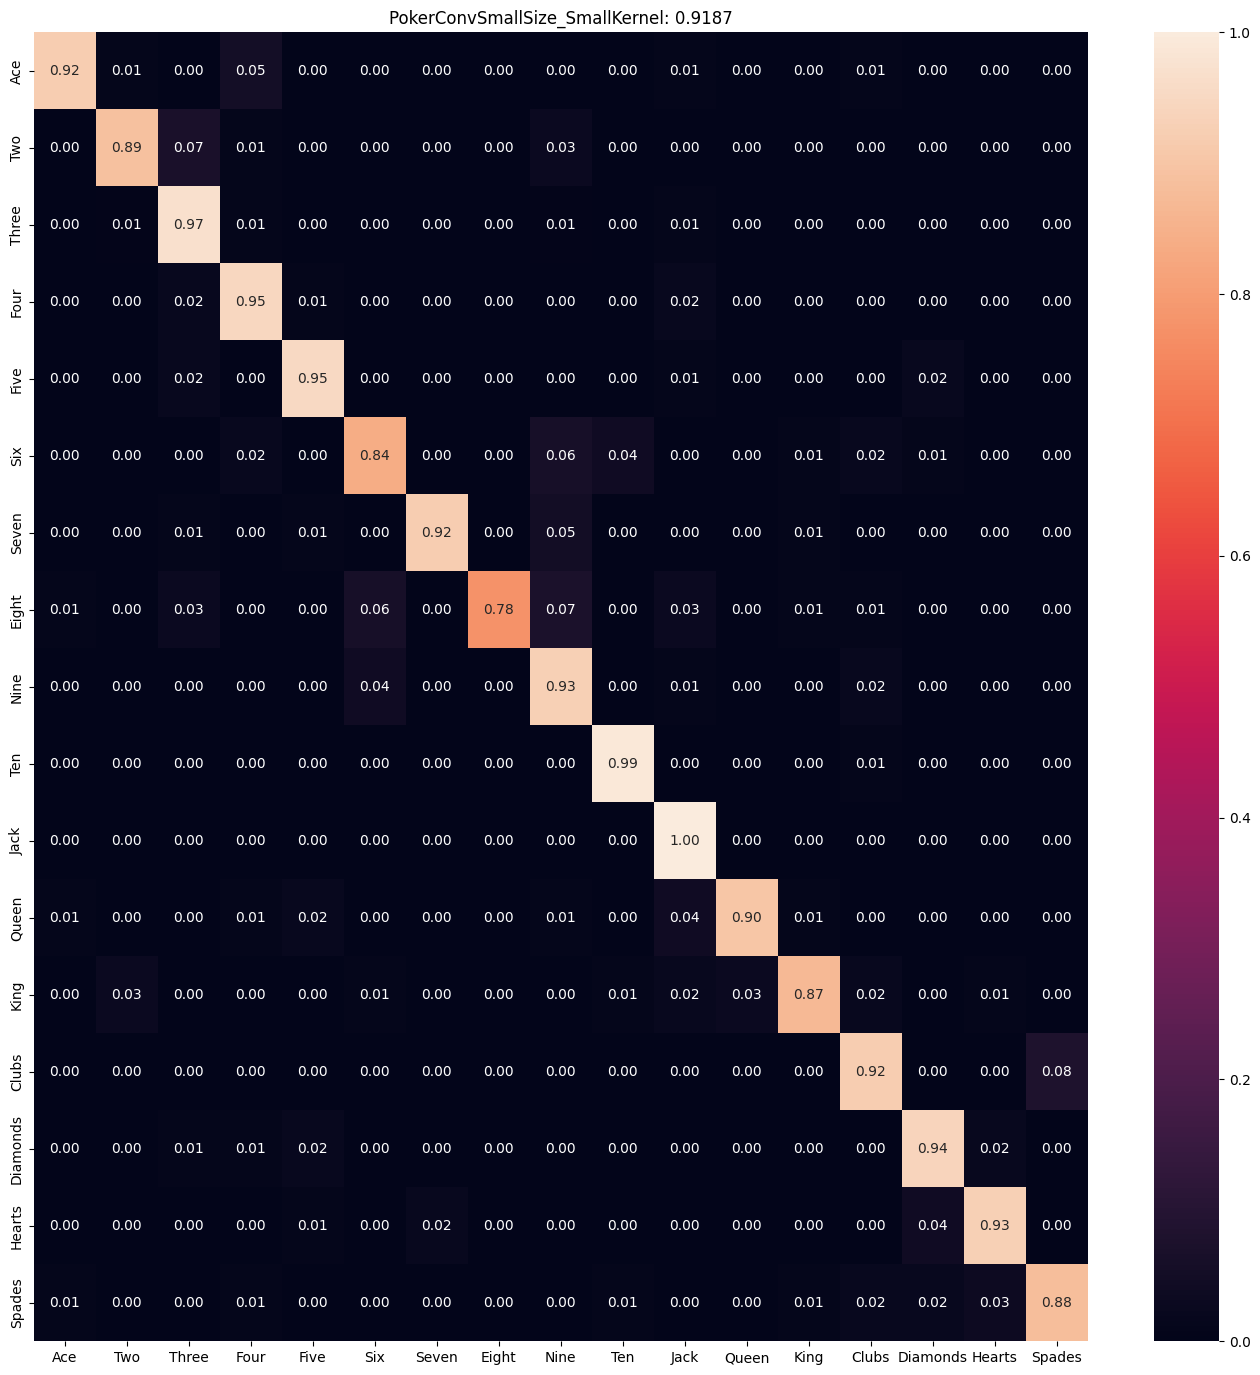

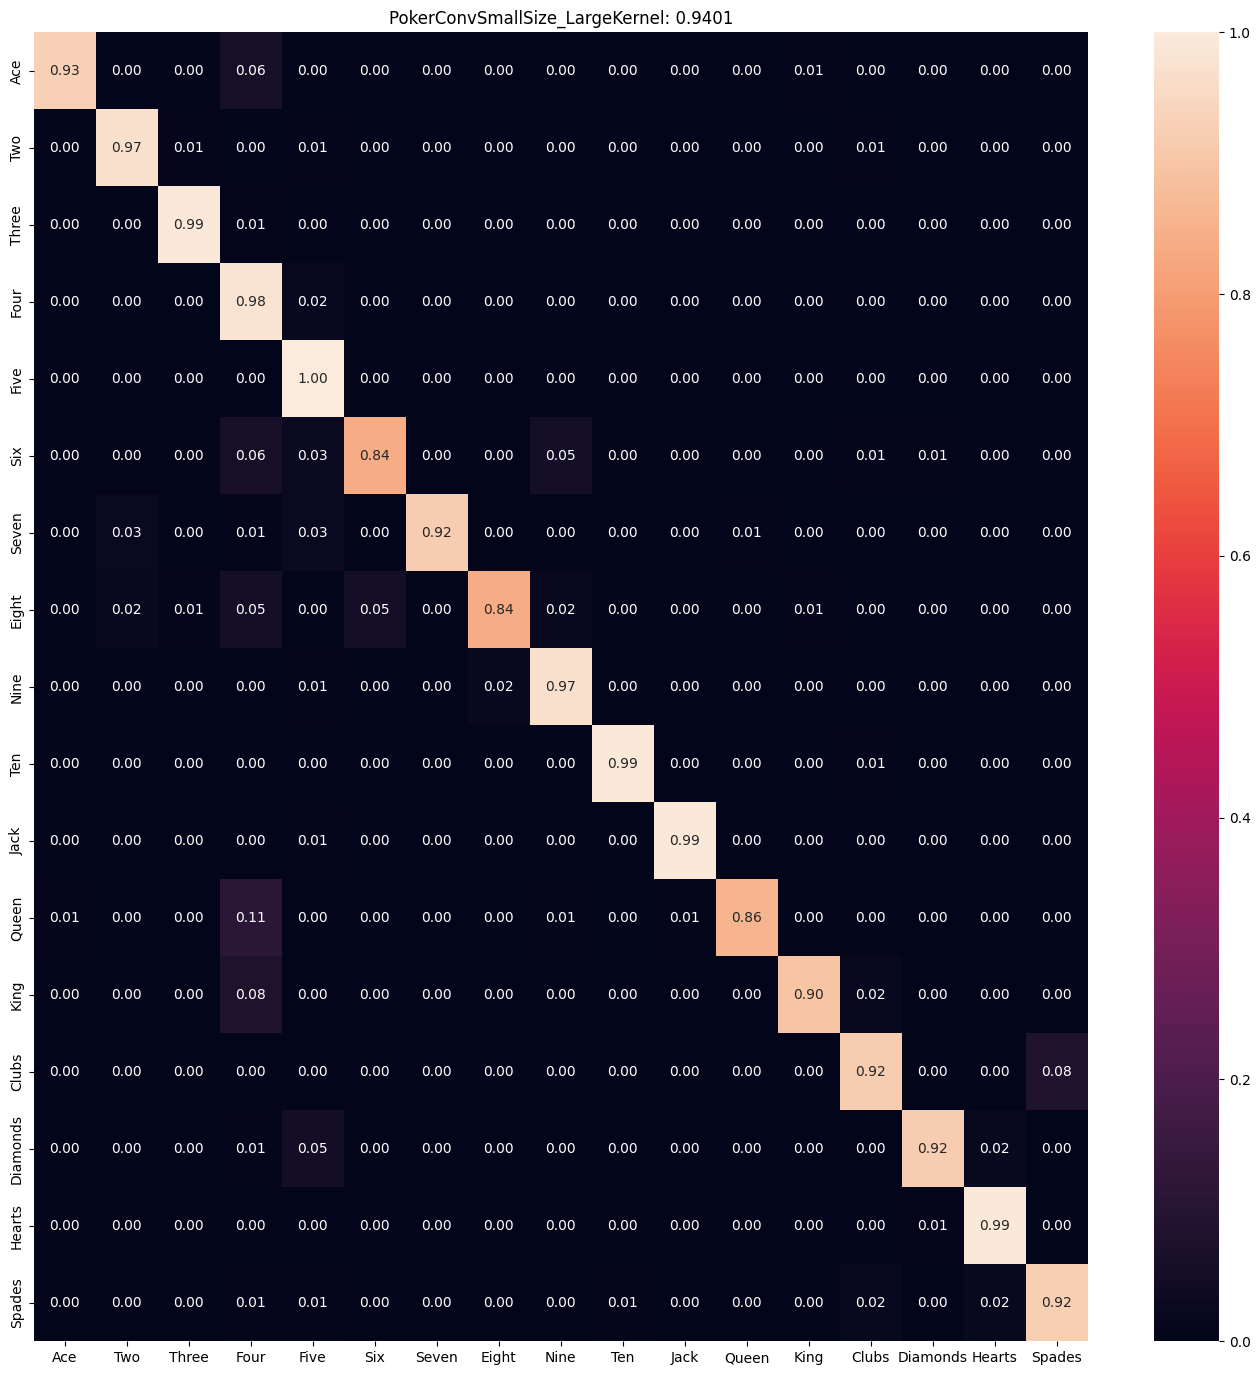

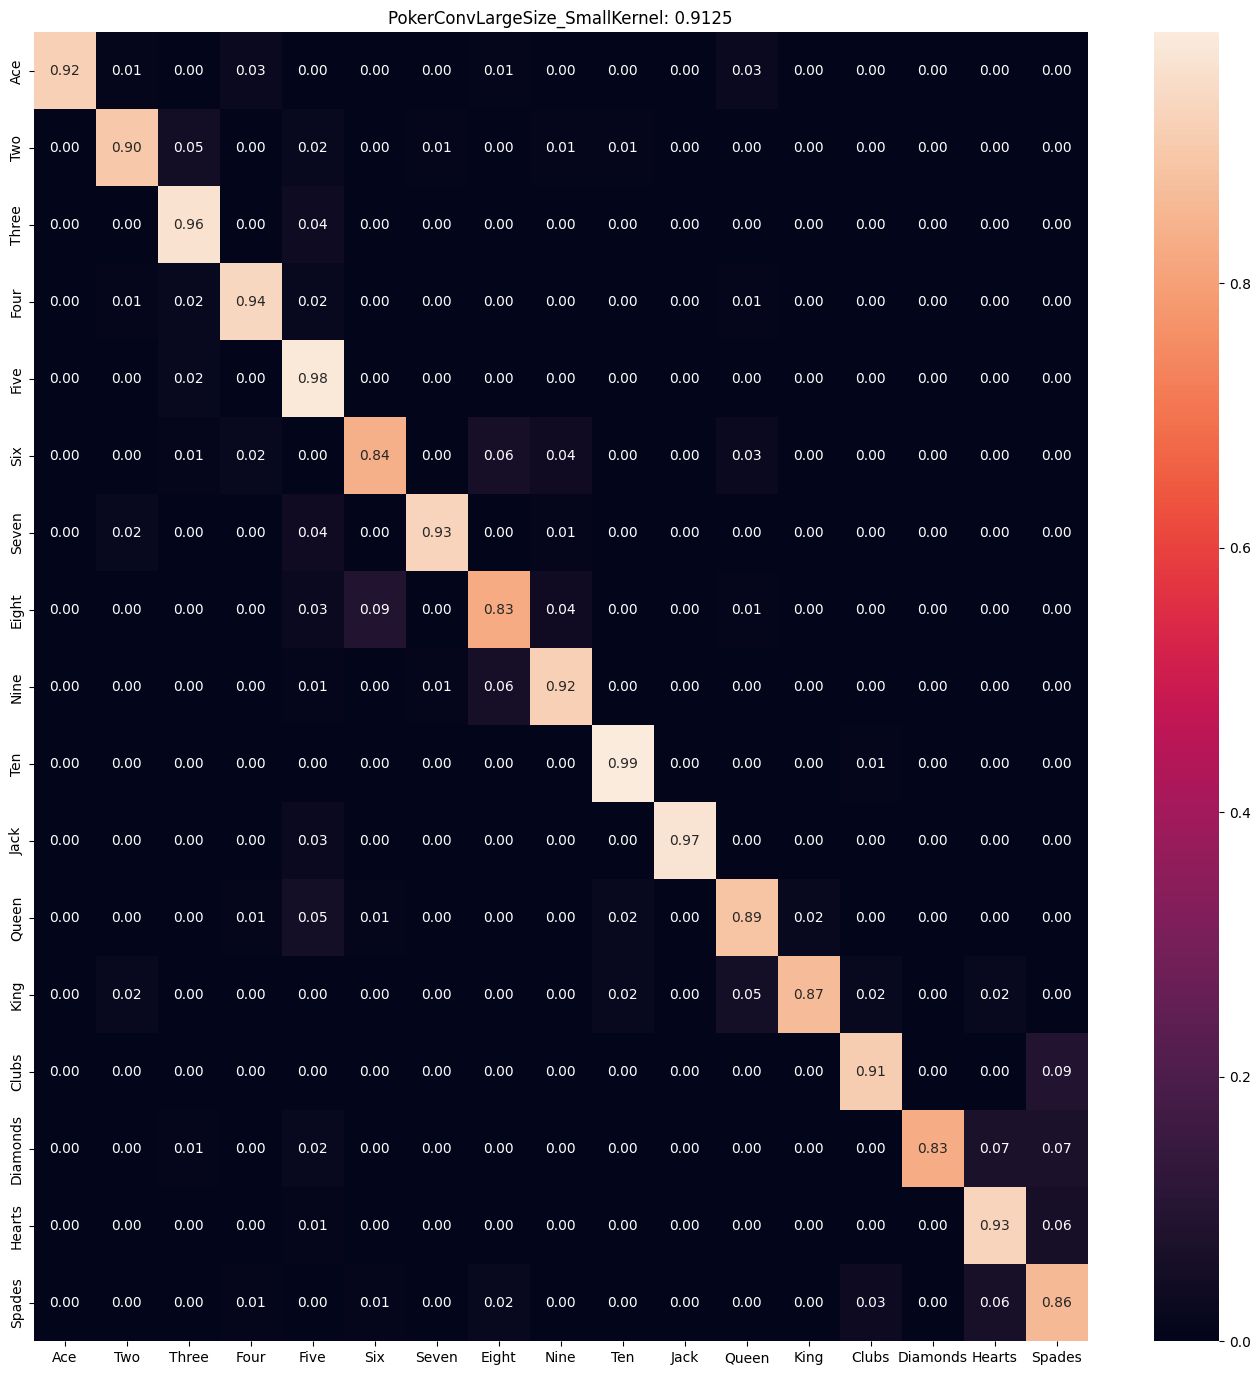

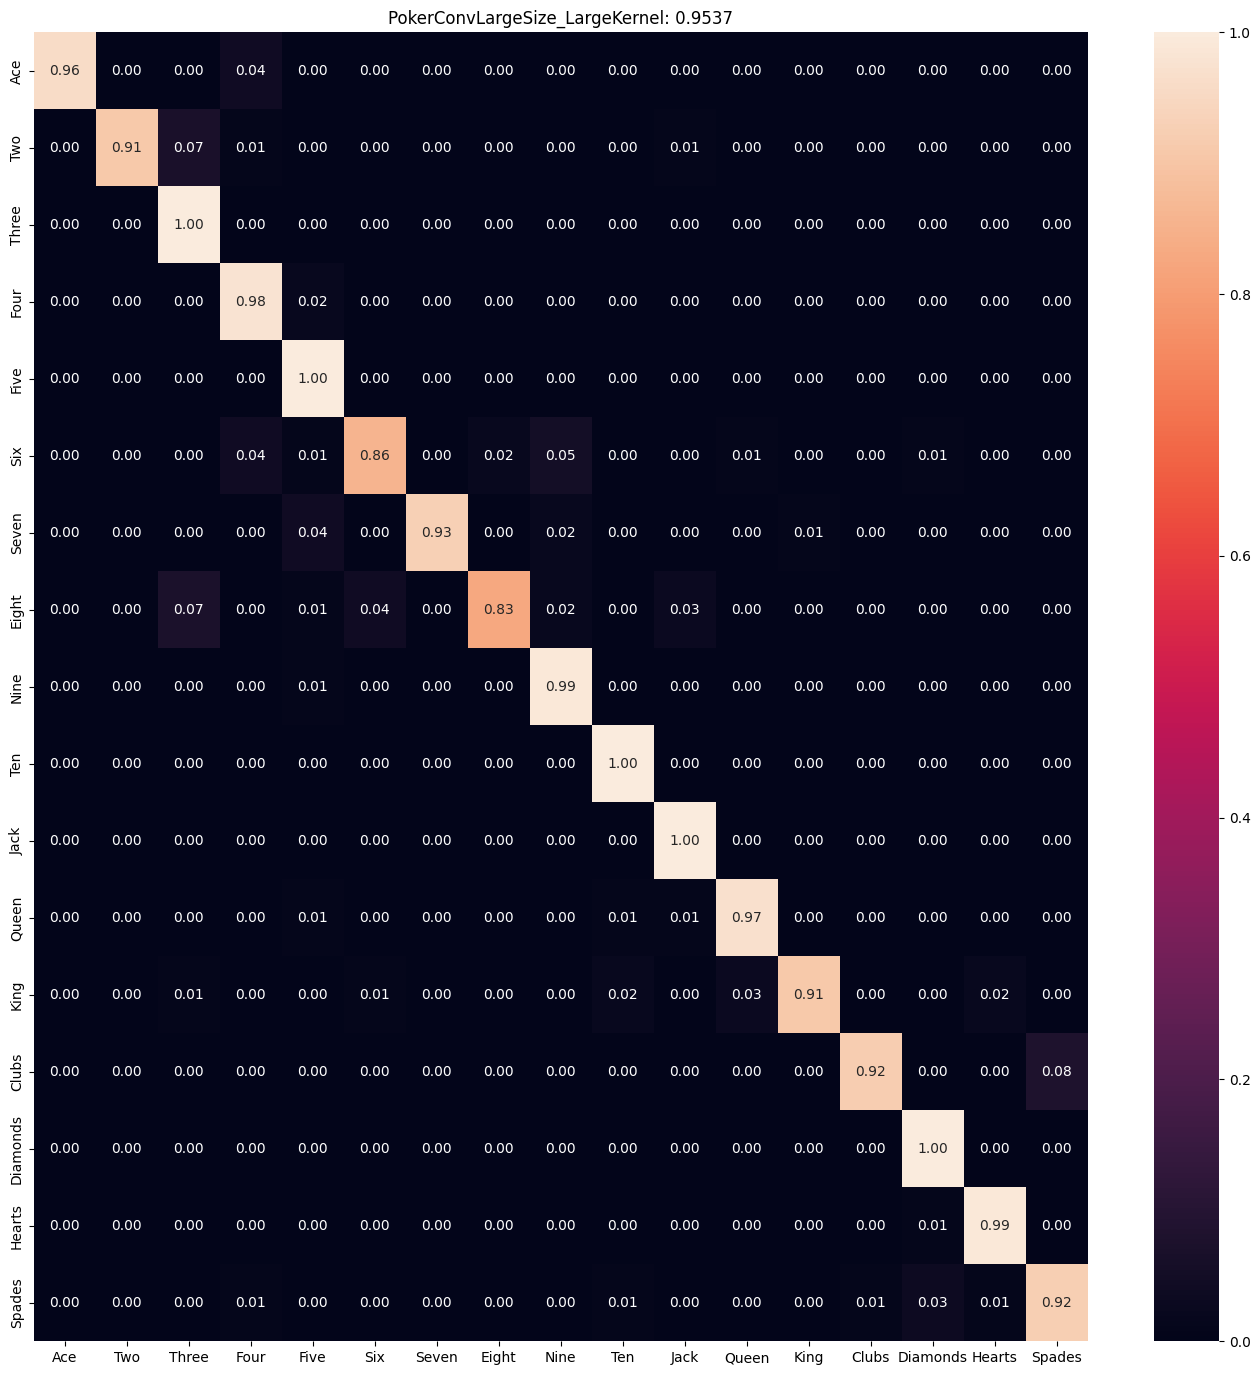

In [11]:
compare_models([cnn1], ds_test, fig_size=(17, 17), labels=labels)
compare_models([cnn2], ds_test, fig_size=(17, 17), labels=labels)
compare_models([cnn3], ds_test, fig_size=(17, 17), labels=labels)
compare_models([cnn4], ds_test, fig_size=(17, 17), labels=labels)

visualizing: PokerConvSmallSize_SmallKernel...


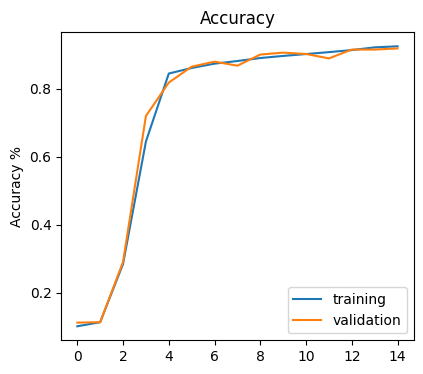

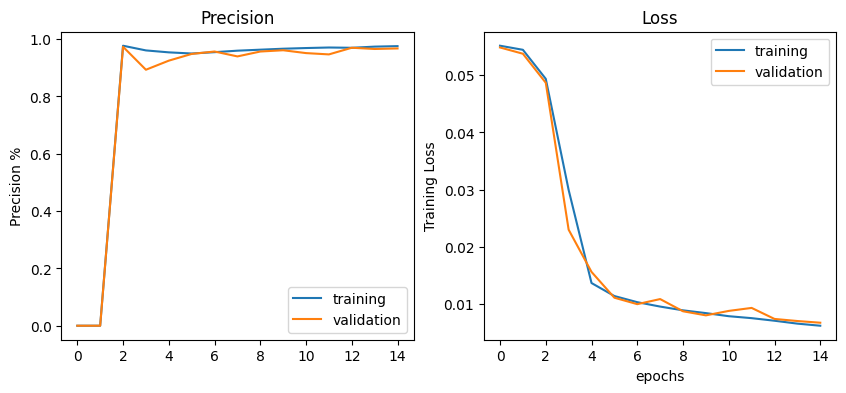

visualizing: PokerConvSmallSize_LargeKernel...


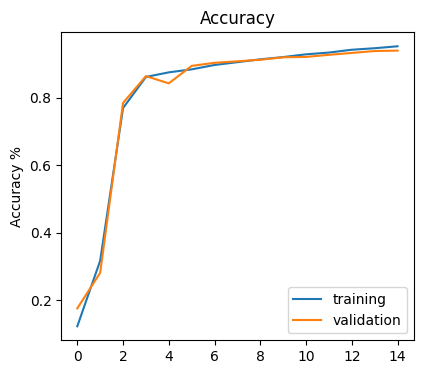

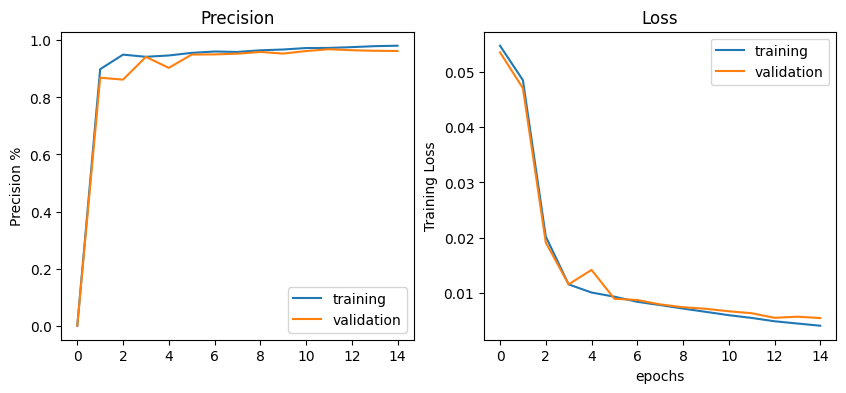

visualizing: PokerConvLargeSize_SmallKernel...


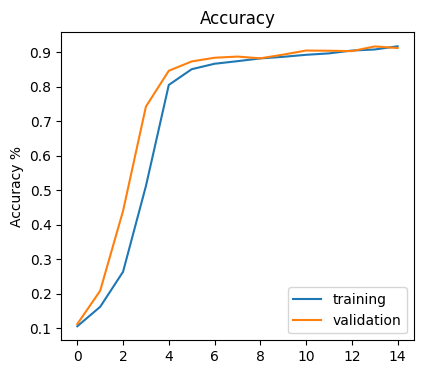

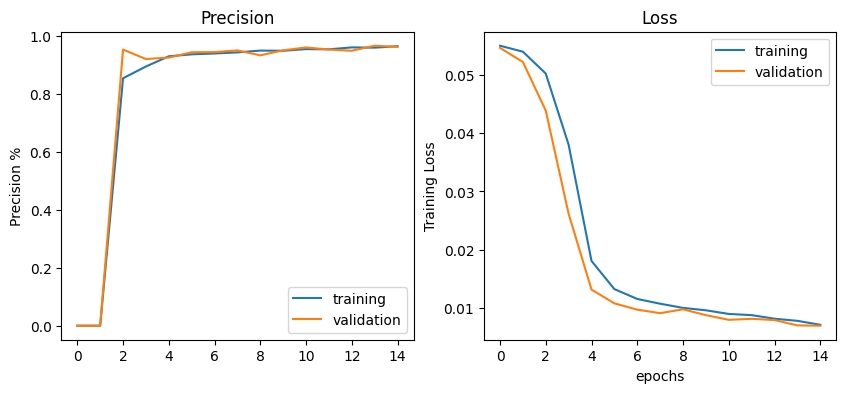

visualizing: PokerConvLargeSize_LargeKernel...


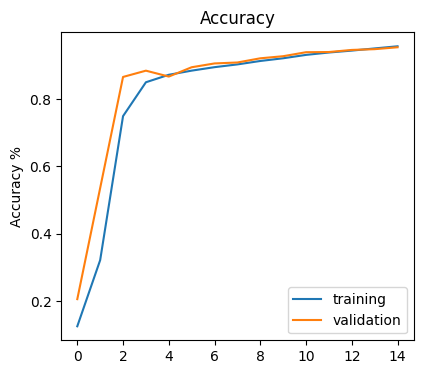

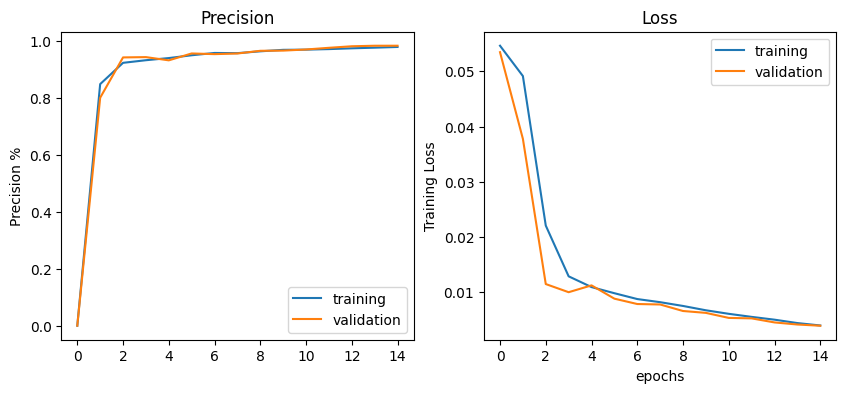

In [19]:
def visualize_performance(history):

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['accuracy'], label='training')

    plt.ylabel('Accuracy %')
    plt.title('Training')
    plt.plot(history['val_accuracy'], label='validation')
    plt.title('Accuracy')
    plt.legend()



    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['precision'], label='training')

    plt.ylabel('Precision %')
    plt.title('Training')
    plt.plot(history['val_precision'], label='validation')
    plt.title('Precision')
    plt.legend()




    plt.subplot(1,2,2)
    plt.plot(history['loss'], label='training')
    plt.ylabel('Training Loss')
    plt.xlabel('epochs')

    plt.plot(history['val_loss'], label='validation')
    plt.xlabel('epochs')
    plt.title('Loss')
    plt.legend()
    plt.show()

    return None

for name, data in histories.items():
    print(f'visualizing: {name}...')
    visualize_performance(data)

Based on the visualization of performance, it is clear that our models do pretty well. The lowest accuracy achieved between all 4 models was .9175. The data shows that the 'PokerConvLargeSize_LargeKernel' model reached the highest accuracy of .9566. Interestingly, the smaller 'PokerConvSmallSize_LargeKernel' model with a smaller num_dense_layers reached the second highest accuracy of .9531. These results indicate that the kernel size may have a strong correlation to the model accuracy. In our case, a kernel size of 5x5 generally resulted in a more accurate model than a 3x3 kernel. 

## Evaluation Metrics Beyond Accuracy

Accuracy is useful as a quick reference, but it is not the strongest metric for this task because it only reports the overall percentage of correct predictions. In a multi-class image classification problem, accuracy can hide which specific card classes are being confused. For example, a model may perform well overall but still struggle with visually similar categories.

For that reason, we use macro precision, macro recall, macro F1-score, ROC-AUC, and confusion matrices. Macro averaging treats each class equally, which is helpful because we want the model to perform consistently across all card labels rather than only doing well on the most common or easiest classes. Precision shows how reliable each predicted class is, recall shows how well the model captures the true examples of each class, and F1-score balances both. ROC-AUC evaluates how well the model separates classes across decision thresholds. The confusion matrix gives a more interpretable view of the actual mistakes made by the model.

AI tools were used in the process of creating some of the sections in the notebook


Here we compare the CNN models to a basic MLP model

In [20]:
%%time

input_shape = [40,28,1]
# make a keras MLP
mlp = Sequential(name='MLP')
mlp.add( Input(input_shape) )
mlp.add( Flatten() )
mlp.add( Dense(units=100, activation='relu') )
mlp.add( Dense(units=50, activation='relu') )
mlp.add( Dense(units=50, activation='relu') )
mlp.add( Dense(NUM_CLASSES) )
mlp.add( Activation('softmax') )

mlp.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

print(mlp.summary())

mlp.fit(ds_train, 
        batch_size=32, epochs=15, 
        shuffle=True, verbose=1)

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 1120)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       112,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 17)             │           867 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 17)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,567 (470.96 KB)

 Trainable params: 120,567 (470.96 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2013 - loss: 2.5937
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5451 - loss: 1.7180
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7364 - loss: 1.1440
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7886 - loss: 0.8945
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8208 - loss: 0.7514
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8198 - loss: 0.7243
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8314 - loss: 0.6607
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8404 - loss: 0.6180
Epoch 9/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8411 - loss: 0.5882
Epoch 10/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8470 - loss: 0.5649
Epoch 11/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8507 - loss: 0.5321
Epoch 12/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.85

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


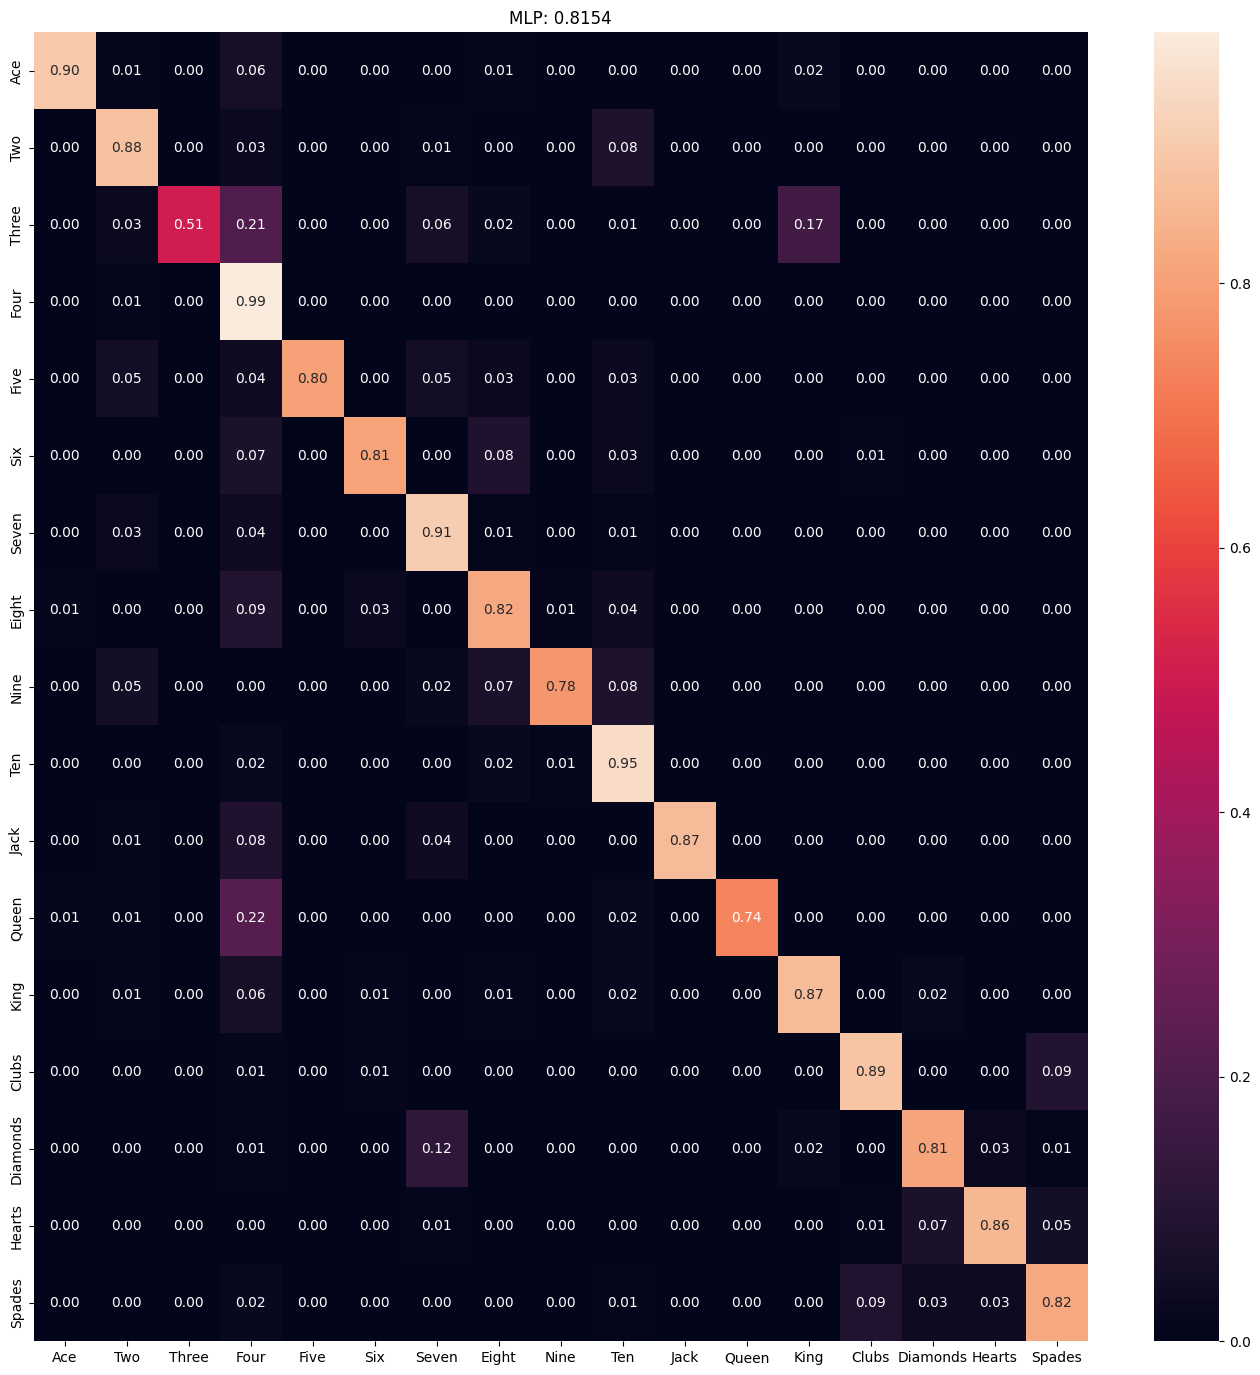

In [21]:
compare_models([mlp], ds_test, fig_size=(17,17), labels=labels)

It is clear that the MLP is much more 'sporatic' compared to the CNN models. This is likely because the MLP looks at the images as a large flat list of numbers whereas the CNN has the benefit of getting context through the kernel which allows it to understand the neighbors of the pixels. 

## Exceptional Work: Transfer Learning with Pretrained Weights

For the exceptional work section, we implemented transfer learning using a pretrained CNN backbone. Transfer learning is appropriate here because pretrained convolutional layers already capture reusable visual features such as edges, textures, shapes, and object-level patterns. This is useful for image classification because our model can start from learned image representations instead of learning every visual feature from scratch.

We compare this transfer learning model against the best CNN model developed above using the same train/test split and evaluation metrics. This keeps the comparison fair and allows us to evaluate whether pretrained image features improve classification performance.

AI tools were used in the process of creating some of the sections in the notebook


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

transfer_model = models.Sequential([
    layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),
    layers.Resizing(224, 224),
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_history = transfer_model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=10
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
52/56 ━━━━━━━━━━━━━━━━━━━━ 25s 6s/step - accuracy: 0.0625 - loss: 3.2711

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(transfer_history.history['accuracy'], label='Training Accuracy')
plt.plot(transfer_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(transfer_history.history['loss'], label='Training Loss')
plt.plot(transfer_history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Transfer Learning Interpretation

The transfer learning model should be compared directly against the best custom CNN from the previous section. If the validation performance is higher or more stable, this suggests that pretrained visual features helped the model generalize better. If the performance is similar or lower, then the custom CNN may already be sufficient for this dataset, or the dataset may differ enough from ImageNet that pretrained features provide less benefit.

Overall, this section extends the original CNN modeling by testing whether pretrained convolutional features improve classification performance under the same evaluation setup.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def get_true_labels(ds):
    y_true = []
    for _, label_tensor in ds:
        y_true.append(label_tensor.numpy())
    return np.argmax(np.vstack(y_true), axis=1)

def evaluate_model(model, ds, model_name):
    y_true = get_true_labels(ds)
    y_prob = model.predict(ds)
    y_pred = np.argmax(y_prob, axis=1)
    result = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }
    try:
        result['ROC-AUC OvR'] = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except ValueError:
        result['ROC-AUC OvR'] = np.nan
    return result

models_to_compare = [cnn1, cnn2, cnn3, cnn4, mlp]
model_results = [evaluate_model(model, ds_test, model.name) for model in models_to_compare]
results_df = pd.DataFrame(model_results).sort_values(by='Macro F1', ascending=False)
results_df


## Model Evaluation Interpretation

The final model comparison should focus primarily on macro F1-score and ROC-AUC rather than accuracy alone. Macro F1-score is useful because it balances precision and recall while giving equal importance to every class. ROC-AUC is useful because it measures how well the model separates classes across decision thresholds. The best model should therefore be selected based on strong validation or test performance across these metrics, not only on the highest training accuracy.

The confusion matrices above help explain the mistakes behind the scores. If a model has lower macro recall, it may be missing certain card classes. If it has lower macro precision, it may be over-predicting some classes. This gives a more complete evaluation than accuracy by itself.
